In [2]:
# 1. Clone the repository
!git clone https://github.com/SatyamSingh-Git/Face-Verification-and-identification-using-Lens-less-camera-and-transformer-model.git
%cd Face-Verification-and-identification-using-Lens-less-camera-and-transformer-model

# 2. Install dependencies (Skipping torch/torchvision as Colab has them optimized)
!pip install -q joblib scikit-learn scipy six tensorboard

# 3. Download and Extract Dataset (Using the fast Missouri Univ link)
import os
import zipfile

%cd /content/
dataset_url = "https://mailmissouri-my.sharepoint.com/:u:/g/personal/chffn_umsystem_edu/IQBgLURyOuKgSrwfl8fLn8ipAY6Ikc-va09tctmaHQaVGcY?e=1Xz4Bo&download=1"

print("Downloading dataset (19GB)... this will take ~10 mins...")
!wget -q -O lensless_data.zip "{dataset_url}"

print("Extracting data...")
if not os.path.exists('lensless_data'):
    with zipfile.ZipFile('lensless_data.zip', 'r') as zip_ref:
        zip_ref.extractall('/content/')
    print("Data Extraction complete!")
else:
    print("Data already extracted.")

# Go back to the repo folder
%cd /content/Face-Verification-and-identification-using-Lens-less-camera-and-transformer-model


Cloning into 'Face-Verification-and-identification-using-Lens-less-camera-and-transformer-model'...
remote: Enumerating objects: 262, done.
remote: Counting objects: 100% (262/262), done.
remote: Compressing objects: 100% (158/158), done.
remote: Total 262 (delta 125), reused 237 (delta 100), pack-reused 0 (from 0)
Receiving objects: 100% (262/262), 21.10 MiB | 39.43 MiB/s, done.
Resolving deltas: 100% (125/125), done.
/content/Face-Verification-and-identification-using-Lens-less-camera-and-transformer-model/Face-Verification-and-identification-using-Lens-less-camera-and-transformer-model
/content
Extracting data...
Data Extraction complete!
/content/Face-Verification-and-identification-using-Lens-less-camera-and-transformer-model


In [5]:
import os
print("Train exists:", os.path.exists('/content/lensless_data/train/ymdct_npy'))
print("Test exists:", os.path.exists('/content/lensless_data/test/ymdct_npy'))


Train exists: True
Test exists: True


In [7]:
!python train.py \
    --model transformer \
    --train_data /content/lensless_data/train/ymdct_npy \
    --test_data /content/lensless_data/test/ymdct_npy \
    --batch_size 128 \
    --num_epoch 15 \
    --seed 42 \
    --resume /content/last.pth


2026-03-15 08:29:27.624990: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773563367.777350   10169 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773563367.824765   10169 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773563368.149714   10169 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773563368.149752   10169 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773563368.149759   10169 computation_placer.cc:177] computation placer alr

In [10]:
!python test_face_recognition.py \
    --model transformer \
    --test_data /content/lensless_data/test/ymdct_npy \
    --weights "{best_weights_path}" \
    --batch_size 32


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/content/Face-Verification-and-identification-using-Lens-less-camera-and-transformer-model/models/transformer_model.py:48: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserW

In [12]:
!python test_face_verification.py \
    --model transformer \
    --test_data /content/lensless_data/test/ymdct_npy \
    --pairs data/verification_pairs.txt \
    --weights "{best_weights_path}"


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/content/Face-Verification-and-identification-using-Lens-less-camera-and-transformer-model/models/transformer_model.py:48: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(
Accuracy = 5046/10092 = 0.5
AUC = 0.9962


Optimal Threshold: 0.9523
At optimal threshold -> TPR: 0.9728, FPR: 0.0190


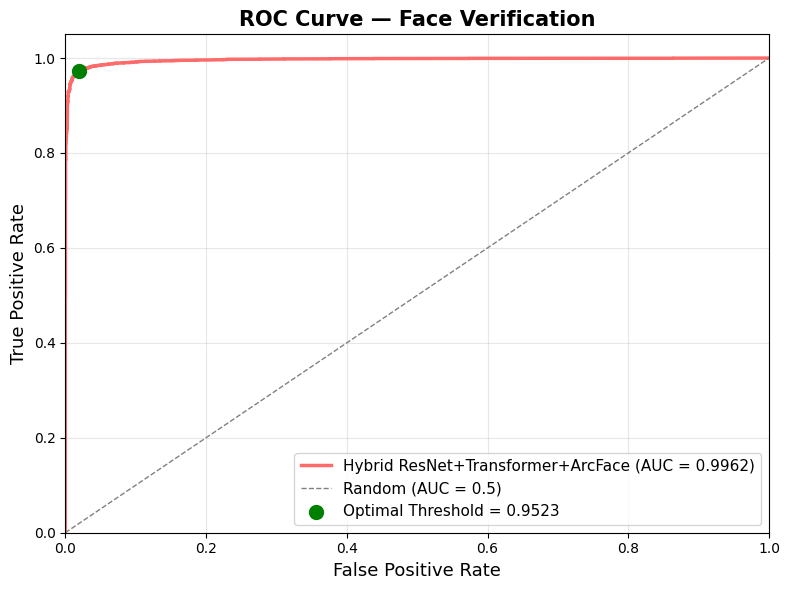

In [13]:
import json
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Load the results
with open('results.json', 'r') as f:
    results = json.load(f)

true_labels = results['true_labels']
pred_scores = results['pred_scores']

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(true_labels, pred_scores)
roc_auc = auc(fpr, tpr)

# Find the optimal threshold (closest to top-left corner)
optimal_idx = (tpr - fpr).argmax()
optimal_thresh = thresholds[optimal_idx]
print(f"Optimal Threshold: {optimal_thresh:.4f}")
print(f"At optimal threshold -> TPR: {tpr[optimal_idx]:.4f}, FPR: {fpr[optimal_idx]:.4f}")

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#FF6B6B', lw=2.5, label=f'Hybrid ResNet+Transformer+ArcFace (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random (AUC = 0.5)')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='green', s=100, zorder=5, label=f'Optimal Threshold = {optimal_thresh:.4f}')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve — Face Verification', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()
